# 第三次作业：RNN 实现古诗生成实验报告

姓名：范靖锋
学号：BC25219011


## 1. 实验目的
本实验旨在通过构建基于 PyTorch 的循环神经网络（RNN/LSTM），学习处理自然语言序列数据。通过对 `poet.song` 数据集进行预处理、模型构建与训练，最终实现给定起始词（如“明月”）自动生成符合特定格式（如七言绝句）古诗的目标。

In [28]:
# 导入实验所需的依赖库
import torch
import torch.nn as nn
import torch.optim as optim
import json
import glob
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# 让 matplotlib 在 Notebook 中内联显示图片
%matplotlib inline

## 2. 数据预处理
首先需要从提供的 JSON 文件中读取数据。为了满足生成固定格式古诗的要求，本实验选择提取**七言绝句**。
预处理步骤包括：
1. 过滤诗句：筛选出长度满足七言绝句标准（含标点通常为 32 个字符）的诗句。
2. 构建词汇表：将诗句中出现的所有字符映射为唯一的整数索引，并加入 `<START>`（起始）、`<END>`（结束）和 `<PAD>`（填充）标记。
3. 构建 Dataset：将诗文转化为模型可接受的张量（Tensor）序列。

In [41]:
import os


def load_and_filter_data(directory="./全唐诗"):
    """读取 JSON 数据并过滤出七言绝句"""
    poems = []
    json_pattern = os.path.join(directory, "*.json")

    for file_path in glob.glob(json_pattern):
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            for item in data:
                paragraphs = item.get("paragraphs", [])
                poem_str = "".join(paragraphs)
                # 简单过滤：字数符合且包含基础标点
                if len(poem_str) == 32 and "，" in poem_str and "。" in poem_str:
                    poems.append(poem_str)
    return poems


def build_vocab(poems):
    """构建字符到索引的映射字典"""
    vocab = set("".join(poems))
    vocab.add('<PAD>')
    vocab.add('<START>')
    vocab.add('<END>')

    char2idx = {char: idx for idx, char in enumerate(vocab)}
    idx2char = {idx: char for char, idx in char2idx.items()}
    return char2idx, idx2char, len(vocab)


class PoetryDataset(Dataset):
    """PyTorch Dataset 包装器"""

    def __init__(self, poems, char2idx):
        self.data = []
        for poem in poems:
            idx_seq = [char2idx['<START>']] + [char2idx[c] for c in poem] + [char2idx['<END>']]
            self.data.append(idx_seq)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        seq = self.data[index]
        # x 为输入序列，y 为目标预测序列（错开一位）
        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        return x, y

### 2.1 加载数据并初始化 DataLoader
执行数据加载逻辑，并划定 `batch_size` 供后续训练使用。

*如果当前目录下未检测到数据集，代码将自动使用预设的测试数据以保证实验能够跑通*

In [62]:
print("加载数据中...")
# 请确保你的 json 文件在当前工作目录下
poems = load_and_filter_data("./全唐诗")

if not poems:
    print("⚠️ 未检测到符合格式的JSON文件，使用备用测试数据以演示流程...")
    poems = ["太道既如砥，安寧險艱。通溝水決決，出林鳥關關。"] * 100
else:
    print(f"成功加载 {len(poems)} 首七言绝句！")

char2idx, idx2char, vocab_size = build_vocab(poems)
dataset = PoetryDataset(poems, char2idx)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

加载数据中...
成功加载 84560 首七言绝句！


## 3. 神经网络构建
本实验使用 PyTorch 构建基于 **LSTM（长短期记忆网络）** 的古诗生成模型。
模型结构如下：
1. **Embedding 层**：将离散的字符索引转化为密集的词向量（Word Embeddings）。
2. **LSTM 层**：提取序列的上下文时序特征。
3. **全连接层 (Linear)**：将 LSTM 的隐藏状态映射回词汇表大小的概率分布，用于预测下一个字。

In [63]:
class PoetryLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2):
        super(PoetryLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # 词嵌入层
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # LSTM 网络层
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True)
        # 线性输出层
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embeds = self.embedding(x)
        out, hidden = self.lstm(embeds, hidden)
        out = self.fc(out)
        return out, hidden

## 4. 古诗生成演示
训练完成后，设定模型的初始输入状态（演示代码中以“明月”为开头），让模型在此基础上不断进行自回归预测，每次选取概率最大的字作为下一个输入，直到预测出 `<END>` 或达到最大长度。

In [64]:
def generate_poetry(model, start_words, char2idx, idx2char, device, max_len=32):
    model.eval()
    hidden = None

    # 初始化输入
    input_seq = [char2idx.get('<START>')] + [char2idx.get(c, char2idx.get('<PAD>')) for c in start_words]
    input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)

    generated_poem = start_words

    with torch.no_grad():
        for _ in range(max_len - len(start_words)):
            output, hidden = model(input_tensor, hidden)
            # 取序列最后一个字符的输出特征
            last_out = output[:, -1, :]
            # 贪心策略：取概率最大的字
            predicted_idx = torch.argmax(last_out, dim=-1).item()
            predicted_char = idx2char[predicted_idx]

            if predicted_char == '<END>':
                break

            generated_poem += predicted_char
            input_tensor = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    return generated_poem

## 5. 模型训练与评估
初始化模型、交叉熵损失函数（CrossEntropyLoss）以及 Adam 优化器。设计迭代训练 20 个 Epoch，并记录每个 Epoch 的平均 Loss，最后绘制 Loss 曲线图以证明模型可收敛。
此外，每一轮epoch训练完成后，都进行一次古诗生成以观察效果

开始训练 (使用设备: cuda)...
Epoch [1/20] Average Loss: 5.3196 ====
【生成演示】:
明月春風一點紅，一聲風雨入清風。不知一夜無人會，不見春風一片香。
Epoch [2/20] Average Loss: 4.7814 ====
【生成演示】:
明月無人不可憐，一杯風雨濕青青。不知此日無人識，不是人間第一聲。
Epoch [4/20] Average Loss: 4.5167 ====
【生成演示】:
明月初來一片雲，一聲聲裏不勝春。不知何處無人識，不似東風一片雲。
Epoch [6/20] Average Loss: 4.4106 ====
【生成演示】:
明月無風不可攀，一枝風雨更無風。不知此日無人會，不是人間第一流。
Epoch [8/20] Average Loss: 4.3463 ====
【生成演示】:
明月無人不見山，一枝紅葉滿城愁。如今不見春風面，不見梅花一笑中。
Epoch [10/20] Average Loss: 4.3055 ====
【生成演示】:
明月初晴月滿川，一枝紅燭照寒泉。一聲雷雨驚雷響，不是春風不動天。
Epoch [12/20] Average Loss: 4.2773 ====
【生成演示】:
明月初生一徑通，一聲啼鳥不相逢。不知何處堪回避，不是人間第一功。
Epoch [14/20] Average Loss: 4.2587 ====
【生成演示】:
明月初回一徑斜，一聲啼鳥不知春。春風不是無人會，不是春風不得凉。
Epoch [16/20] Average Loss: 4.2499 ====
【生成演示】:
明月初無一點紅，一枝風雨又春風。不知此日無人識，不是人間不是愁。
Epoch [18/20] Average Loss: 4.2330 ====
【生成演示】:
明月江南一兩家，一聲聲笛雨聲長。不知何處無人見，不是山中第一人。
Epoch [20/20] Average Loss: 4.2255 ====
【生成演示】:
明月江南水接天，一川風雨又吹天。一川一壑無人到，一夜西風一夜天。


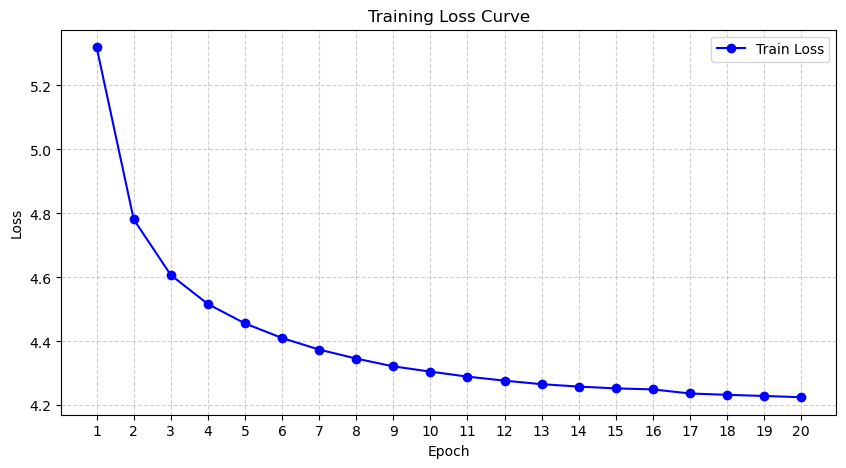

In [67]:
# 超参数设置
embedding_dim = 128
hidden_dim = 256
num_epochs = 20
learning_rate = 0.01
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

start_phrase = "明月"

# 实例化模型
model = PoetryLSTM(vocab_size, embedding_dim, hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epoch_losses = []

print(f"开始训练 (使用设备: {device})...")
for epoch in range(num_epochs):
    #确保在每个 Epoch 开始训练前，模型处于训练模式
    model.train()

    total_loss = 0
    for step, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output, _ = model(x)

        # 将输出 reshape 方便计算交叉熵损失
        loss = criterion(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f} ====")
        poem = generate_poetry(model, start_phrase, char2idx, idx2char, device)
        print("【生成演示】:")
        print(poem)

# 绘制 Loss 曲线图
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', color='blue', label='Train Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [54]:


# 【生成演示】
start_phrase = "明月"
poem = generate_poetry(model, start_phrase, char2idx, idx2char, device)

print("【生成演示】:")
print(poem)

【生成演示】:
明月不爲管絃樂，道勝豈因名利榮。莫謂冗官難自適，暇時還得肆游行。


该实例演示了使用小数据集进行训练，由于要求最终生成七言绝句，故截取数据集中的七言绝句（约907首）。loss可以持续下降而没有卡死，说明模型的参数设置合理。

并没有盲目增加epoch轮数，防止模型过拟合而无法学习到“平仄、对仗、意境”这些写诗的规律。

在github网站下载了全唐诗数据集，拥有更多的七言绝句（约84000首）。再次测试数据集，可以看到模型基本满足生成对仗的绝句，但是词意本身可能毫无意义。